In [201]:
# import the required libraries 
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
import random  
import math

# Compito da consegnare

In [203]:
def f(x): # deterministic force
    f = 0
    return f

def xi(t): # random force
    mu = 0
    sigma = 1
    xi = random.gauss(mu, sigma)
    return xi

def chi(t): # first random variable
    mu = 0
    sigma = 1
    chi = random.gauss(mu, sigma)
    return chi

def theta(i): # second random variable
    mu = 0
    sigma = 1
    theta = random.gauss(mu, sigma)
    return theta

def A(i):
    A = 0.5*dt^2*(f(x(i)) - 1/tau * v(i)) + math.sqrt(2*Kb*T/(m*tau))*math.pow(dt,3/2)*(0.5*chi(i) + 0.5/math.sqrt(3) * theta(i))
    return A

In [204]:
tau = 1 # timescale
m = 1 # mass
Kb = 1 # Boltzmann constant
T = 1 # temperature

dt = 0.01 # time discretization 
iterations = 100

In [205]:
x_val = [0]
x = 0

for i in range(iterations):
    x = x_val[i] + dt*(tau/m)*f(x_val[i]) + math.sqrt(2*Kb*T*tau/m)*math.sqrt(dt)*chi(i)
    x_val.append(x)

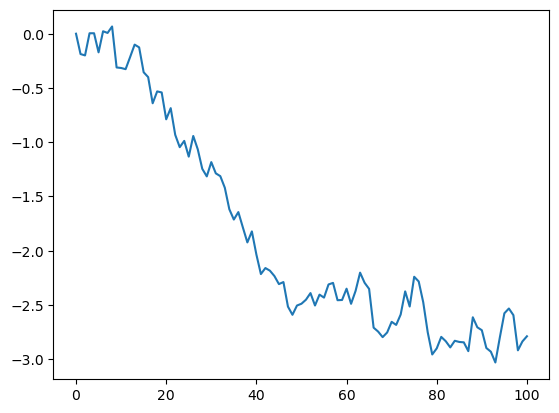

In [206]:
# plotting a graph  
plt.plot(x_val)  
plt.show() 

# quinto esempio: langevin gpt

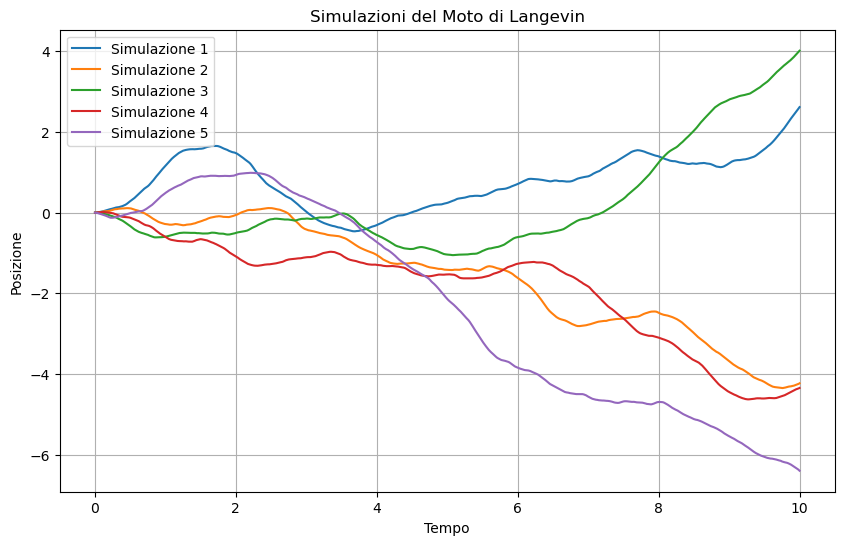

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Funzione per eseguire una singola simulazione del moto di Langevin
def langevin_simulation(simulation_id, steps, dt, gamma, kBT, F_deterministic):
    """
    Simulazione numerica dell'equazione di Langevin usando il metodo di Euler-Maruyama.
    
    Parametri:
        simulation_id (int): Identificatore della simulazione.
        steps (int): Numero di passi temporali.
        dt (float): Passo temporale.
        gamma (float): Coefficiente di attrito viscoso.
        kBT (float): Energia termica (Boltzmann * T).
        F_deterministic (float): Forza deterministica costante (default = 0.0).
        
    Ritorna:
        np.ndarray: Posizioni della particella nel tempo.
    """
    mu = 0.0
    sigma = 1.0
    
    np.random.seed()  # Genera casualità unica per ogni simulazione
    
    # Inizializzazione delle variabili
    x = 0.0  # Posizione iniziale
    v = 0.0  # Velocità iniziale
    trajectory = [x]  # Tracciamento della traiettoria
    
    # Simulazione iterativa
    for _ in range(steps):
        # Forza casuale (rumore gaussiano)
        F_random = np.sqrt(2 * gamma * kBT / dt) * np.random.normal(mu,sigma)
        
        # Equazione di Langevin discreta
        v += (-gamma * v + F_deterministic + F_random) * dt
        x += v * dt
        
        trajectory.append(x)
    
    return np.array(trajectory)

# Parametri generali
num_simulations = 5  # Numero di simulazioni
steps = 1000         # Numero di passi temporali
dt = 0.01            # Passo temporale
gamma = 1.0          # Attrito viscoso
kBT = 1.0            # Energia termica
F_deterministic = 0.0  # Forza esterna (ad esempio, 0.0 per ora)

# Esecuzione delle simulazioni
all_simulations = []
for i in range(num_simulations):
    sim_data = langevin_simulation(
        simulation_id=i, steps=steps, dt=dt, gamma=gamma, kBT=kBT, F_deterministic=F_deterministic
    )
    all_simulations.append(sim_data)

# Plot dei risultati
time = np.arange(steps + 1) * dt  # Array temporale
plt.figure(figsize=(10, 6))
for i, sim_data in enumerate(all_simulations):
    plt.plot(time, sim_data, label=f"Simulazione {i+1}")

plt.title("Simulazioni del Moto di Langevin")
plt.xlabel("Tempo")
plt.ylabel("Posizione")
plt.legend()
plt.grid()
plt.show()

# quatro esempio: multiple random plot

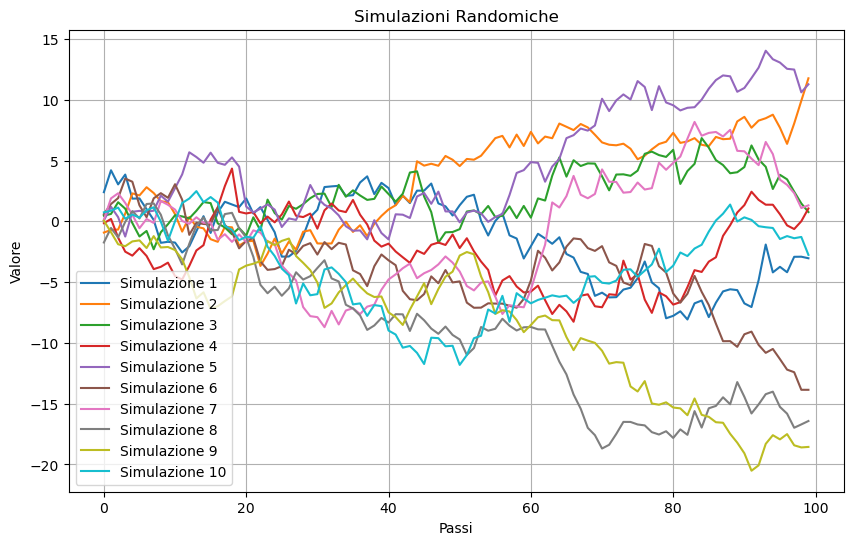

In [218]:
import numpy as np
import matplotlib.pyplot as plt

# Funzione per eseguire una singola simulazione
def single_simulation(simulation_id, steps=100):
    np.random.seed()  # Mantieni casualità indipendente per ogni simulazione
    data = np.cumsum(np.random.randn(steps))  # Simulazione di un moto browniano
    return data

# Parametri
num_simulations = 10  # Numero di simulazioni
steps = 100           # Numero di step per simulazione

# Esecuzione delle simulazioni
all_simulations = []
for i in range(num_simulations):
    sim_data = single_simulation(simulation_id=i, steps=steps)
    all_simulations.append(sim_data)

# Plot dei risultati
plt.figure(figsize=(10, 6))
for i, sim_data in enumerate(all_simulations):
    plt.plot(sim_data, label=f"Simulazione {i+1}")

plt.title("Simulazioni Randomiche")
plt.xlabel("Passi")
plt.ylabel("Valore")
plt.legend()
plt.grid()
plt.show()

# primo esempio: single diff eq

In [208]:
def returns_dydt(y,t):
    dydt = -y * t + 13
    return dydt

In [209]:
# y value at time 0
y0 = 0
# values of time - from 0 to 5.
t = np.linspace(0,50,100)
# solving ODE
y_result = odeint(returns_dydt, y0, t)

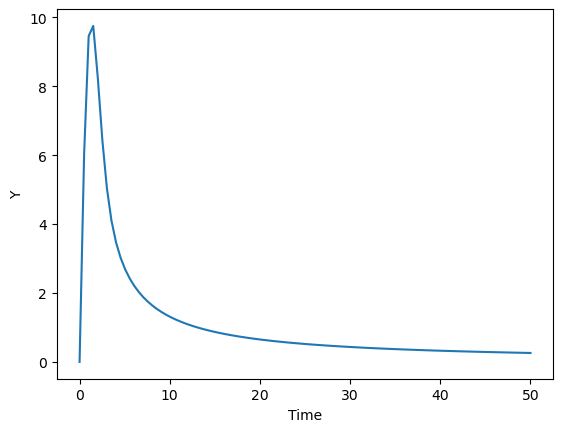

In [210]:
# plot results
plt.plot(t,y_result)
plt.xlabel("Time")
plt.ylabel("Y")
plt.show()

# secondo esempio: system of diff eq

In [212]:
def dYdx(Y, x):
    y1, y2 = Y
    return [2 * y2 + x, 
           2 * y1 + 3 * np.sin(x)]

In [213]:
# y1 and y2 values at time 0
y1_0 = 0
y2_0 = 1

# Vector of indipendent variable
x = np.linspace(0, 1, 50)
# Solution
sol = odeint(dYdx, (y1_0, y2_0), x)

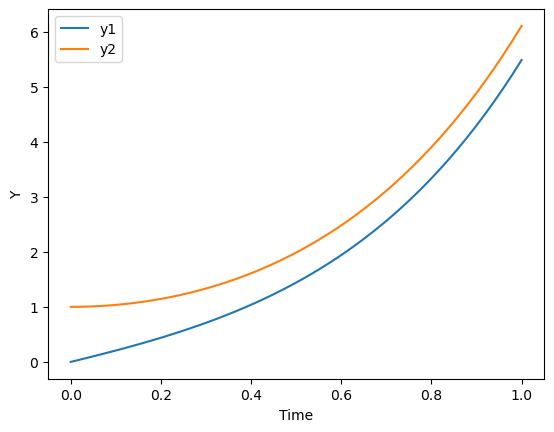

In [214]:
# Unpack variables
y1 = sol[:,0]
y2 = sol[:,1]

# Plot
plt.plot(x, y1, label='y1')
plt.plot(x,y2, label='y2')
plt.xlabel("Time")
plt.ylabel("Y")
plt.legend(loc='upper left')
plt.show()

# terzo esempio: random

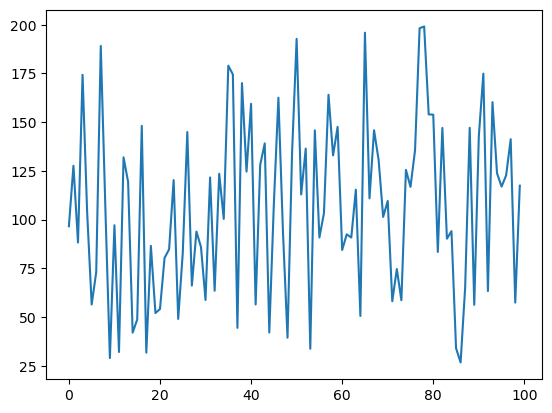

In [216]:
# store the random numbers in a   
# list  
nums = []  
mu = 100
sigma = 50
    
for i in range(100):  
    temp = random.gauss(mu, sigma) 
    nums.append(temp)  
        
# plotting a graph  
plt.plot(nums)  
plt.show() 